### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)


In [8]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [9]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv.name)

arxiv


In [10]:
arxiv.invoke("Attention iss all you need")

HTTPError: Page request resulted in HTTP 429 (https://export.arxiv.org/api/query?search_query=Attention+iss+all+you+need&id_list=&sortBy=relevance&sortOrder=descending&start=0&max_results=100)

In [11]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [12]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed.\nStatistics and mathematical optimisation methods compose the foundations of machine learning. Data mining is a related field of study, focusing on exploratory data analysis (EDA) through unsupervised learning.\nFrom '

In [13]:
### Initialize my llm model 
import os
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="openai/gpt-oss-20b",max_tokens=1024)  # or the exact Groq model identifier


In [14]:
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [15]:
from langchain_tavily import TavilySearch

travily = TavilySearch(
    max_results=5,
    topic="general",
)


In [16]:
travily.invoke({"query": "What happened at the last wimbledon"})

{'query': 'What happened at the last wimbledon',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.the-independent.com/topic/wimbledon',
   'title': 'Wimbledon - latest news, breaking stories and comment - The Independent',
   'content': 'The body was found in a wooded area of Borstal Recreation Ground in Rochester\n\n## Two men charged with murder after body found dumped in woodland\n\n<p>Alexander Zverev plays defending champion Jannik Sinner in his first Wimbledon final </p>\n\n## Why a two-week transformation poses Wimbledon final’s biggest question\n\n<p>Alexander Zverev plays in his first Wimbledon final against Jannik Sinner on Sunday </p>\n\n## Zverev and the allegations casting a cloud over Wimbledon final [...] <p>Linda Noskova appears emotional as she dedicates her Wimbledon victory to her late mother </p>\n\n## Wimbledon champion and finalist crash out at Canadian Open\n\n<p>Jack Draper was in tears as he was knocked out of the 

In [17]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

tools=[arxiv,wiki,add,multiply,divide,travily]

In [18]:
llm_with_tools = llm.bind_tools(tools)

In [19]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer "What is the recent AI News". Likely need to provide recent AI news. We can search the web. Use tavily_search.', 'tool_calls': [{'id': 'fc_41b313ac-5af8-4ad0-9701-f10dd522e49b', 'function': {'arguments': '{"query":"recent AI news 2026","search_depth":"advanced","time_range":"day","topic":"news"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 77, 'prompt_tokens': 537, 'total_tokens': 614, 'completion_time': 0.081907355, 'completion_tokens_details': {'reasoning_tokens': 33}, 'prompt_time': 0.026442644, 'prompt_tokens_details': None, 'queue_time': 0.346802921, 'total_time': 0.108349999}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e189667b30', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a09994-9ed4-77e3-8cd0-0cc3ddd95d42-0', tool_calls=[{'name': 'tavily_searc

In [20]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search',
  'args': {'query': 'recent AI news 2026',
   'search_depth': 'advanced',
   'time_range': 'week',
   'topic': 'news'},
  'id': 'fc_92c44424-c74d-4913-8e0f-0c749351eabd',
  'type': 'tool_call'}]

In [21]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

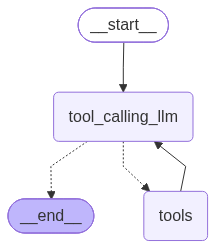

In [22]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

graph = StateGraph(State)

graph.add_node("tool_calling_llm",tool_calling_llm)
graph.add_node("tools",ToolNode(tools))

graph.add_edge(START , "tool_calling_llm")
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

graph.add_edge("tools","tool_calling_llm")

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [23]:
messages=graph_builder.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for MArch 3rd 2025,add 5 plus 5 and then multiply by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_0e316cf0-7447-4f2c-b214-b85d8e932d0f)
 Call ID: fc_0e316cf0-7447-4f2c-b214-b85d8e932d0f
  Args:
    query: March 3 2025 AI news
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "March 3 2025 AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://choreoadvisors.com/market-perspectives/march-2025-the-artificial-intelligence-revolution", "title": "March 2025 - The Artificial Intelligence Revolution", "content": "There are plenty of signs that AI is beginning to have a material effect on the world. One of the early signals may be the valuation of AI-related private companies s

In [24]:
messages=graph_builder.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning** is a subfield of artificial intelligence (AI) that focuses on building algorithms and statistical models that enable computers to improve their performance on a specific task through experience, without being explicitly programmed for each instance.

Key ideas:

1. **Data‑driven learning** – Instead of hard‑coding rules, a model learns patterns from data (examples, observations, or measurements).
2. **Model training** – The learning process adjusts the model’s parameters to minimize errors (or maximize some objective) on a training dataset.
3. **Generalization** – After training, the model is expected to perform well on new, unseen data, capturing underlying structure rather than memorizing the training set.
4. **Algorithms** – Common families include:
   - **Supervised learning*

### Agent Memory
#### Aim 
lets introduce memory in the agents

In [26]:
messages=graph_builder.invoke({"messages":HumanMessage(content="what is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

what is 5 plus 8
================================== Ai Message ==================================

5 + 8 = 13.


In [32]:
messages=graph_builder.invoke({"messages":HumanMessage(content="Divide that by 5")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

I’m not sure what number you’d like to divide by 5. Could you let me know which value you’re referring to?


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

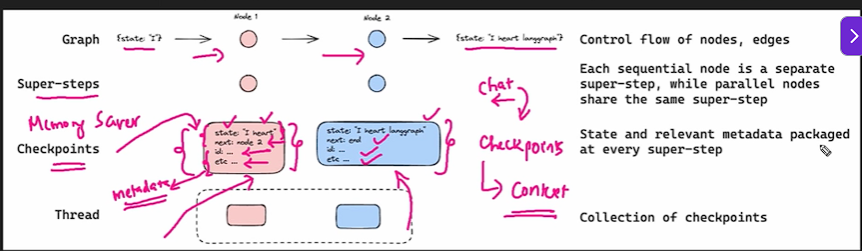

In [33]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

graph = StateGraph(State)

graph.add_node("tool_calling_llm",tool_calling_llm)
graph.add_node("tools",ToolNode(tools))

graph.add_edge(START , "tool_calling_llm")
graph.add_conditional_edges(
    "tool_calling_llm",
    tools_condition
)

graph.add_edge("tools","tool_calling_llm")



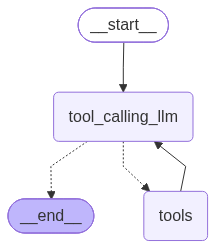

In [34]:

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
graph_memoryy = graph.compile(checkpointer=memory)

## View
display(Image(graph_memoryy.get_graph().draw_mermaid_png()))

In [37]:
## Specify the thread 

config = {"configurable":{"thread_id":"1"}}

# Specify an input 

messages = [HumanMessage(content="Add 13 and 14")]
messages=graph_memoryy.invoke({"messages":messages},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 13 and 14
================================== Ai Message ==================================
Tool Calls:
  add (fc_615c99ac-8428-4d11-a58c-f08fc414bcbf)
 Call ID: fc_615c99ac-8428-4d11-a58c-f08fc414bcbf
  Args:
    a: 13
    b: 14
================================= Tool Message =================================
Name: add

27
================================== Ai Message ==================================

27


In [40]:
messages=graph_memoryy.invoke({"messages":HumanMessage(content="Divide that by 9")},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Add 13 and 14
================================== Ai Message ==================================
Tool Calls:
  add (fc_615c99ac-8428-4d11-a58c-f08fc414bcbf)
 Call ID: fc_615c99ac-8428-4d11-a58c-f08fc414bcbf
  Args:
    a: 13
    b: 14
================================= Tool Message =================================
Name: add

27
================================== Ai Message ==================================

27
================================ Human Message =================================

Divide that by 0
================================== Ai Message ==================================

Division by zero is undefined in standard arithmetic.  
In most programming languages and mathematical systems, attempting to divide by zero will raise an error or result in an undefined value. If you need a specific behavior (e.g., returning `Infinity`, `NaN`, or throwing an exception), please let me know how you'd like t